# Treinamento DeBERTa — versão corrigida (auditoria de vazamento + protocolo de avaliação honesto)

**Diagnóstico do resultado suspeito** (`val_loss ≈ 1e-6`, `accuracy = 1.0` já na 2ª época):

| # | Problema no notebook original | Consequência |
|---|---|---|
| 1 | `dataset.json + contrastive + adaptive + expansion + real` são concatenados e o split é **aleatório por linha** | Textos sintéticos gerados por LLM são quase-duplicados entre si. Variantes do mesmo *seed* caem em treino **e** validação → vazamento direto |
| 2 | Nenhuma deduplicação (nem exata) | Texto idêntico pode estar em treino e validação |
| 3 | `diagnostic_test.json` é concatenado ao teste **sem checar** se já está no pool de treino | Teste contaminado |
| 4 | Negativos sintéticos vêm de outro domínio/vocabulário | Tarefa fica linearmente separável por *bag-of-words*; o modelo aprende estilo, não o construto |
| 5 | ~180 exemplos no total → val ≈ 25 linhas | `accuracy = 1.0` sobre 25 linhas não tem poder estatístico |
| 6 | `label_smoothing_factor=0.1` + `compute_loss` custom | O smoothing é **silenciosamente ignorado** pelo `Trainer` |
| 7 | `temperature` calculada mas depois `test_logits / 0.602` hardcoded | Calibração aplicada errada |
| 8 | `model.config.hidden_dropout_prob` alterado **depois** do `from_pretrained` | Não tem efeito nenhum (os módulos já foram construídos) |
| 9 | `metric_for_best_model="loss"` + só `accuracy` | Com classes desbalanceadas, métrica inútil para *screening* |
| 10 | `eval_steps=240` / `save_steps=120` com `strategy="epoch"` | Ignorados |
| 11 | `DebertaV2Tokenizer` (slow) e `padding="max_length"` em 512 | Treino muito mais lento sem ganho |
| 12 | Treino com `max_length=512`, inferência com `256` | Distribuição de entrada diferente na hora de usar |
| 13 | `test_predictions` referenciado na célula final, mas a variável é `test_outputs` | `NameError` |
| 14 | `expansion_data` é sobrescrito por `diagnostic_test.json` | Confusão de variáveis |

**O que esta versão faz:**
1. Normaliza, deduplica exato e agrupa **quase-duplicados** (TF-IDF + componentes conexos).
2. Faz o split **por grupo** — variantes do mesmo texto nunca se separam entre treino/val/teste.
3. Coloca os abstracts **reais** na avaliação (o sintético serve para treinar), que é a distribuição de deploy.
4. Descontamina o `diagnostic_test.json`.
5. Roda uma **auditoria de separabilidade trivial** (baseline TF-IDF + teste de permutação de rótulos) **antes** de treinar o DeBERTa — se o baseline burro já dá 100%, o 100% do DeBERTa não significa nada.
6. Corrige a focal loss, a calibração, as métricas e os hiperparâmetros.

In [9]:
# ============================================================
# 0. Imports e configuração
# ============================================================
import os, re, json, unicodedata, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, average_precision_score,
    classification_report, confusion_matrix,
)

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------- Reprodutibilidade ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")

# ---------------- Caminhos ----------------
DATA_DIR   = "../model/dataset"
OUTPUT_DIR = "../model/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- Configuração do experimento ----------------
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN    = 384          # usado em TREINO *e* INFERÊNCIA (o original divergia: 512 vs 256)

# Limiar de similaridade para considerar dois textos "quase-duplicados".
# 0.85 pega variação de 1-2 palavras; 0.70 pega paráfrase pesada.
# A célula de diagnóstico plota o histograma para você calibrar isso com SEU corpus.
DUP_THRESHOLD = 0.80

# Protocolo de avaliação:
#   "real_only"      -> val/test compostos APENAS de abstracts reais (recomendado, honesto)
#   "grouped_random" -> split aleatório mas agrupado (usa tudo; menos realista)
EVAL_PROTOCOL = "real_only"

SPLIT_SIZES = (0.70, 0.15, 0.15)

LABEL_MAP = {
    "Not related": 0,
    "Sensing of walkability dimension": 1,  #← Agora casa com seus dados
}
# # ... validação dura que levanta exceção se algo não mapear
# unknown = df.loc[df["label_canon"].isna(), "label"].value_counts()
# if len(unknown):
#     raise ValueError(f"Rotulos nao reconhecidos: {unknown}")
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
POS_ID = 1
print(f"Protocolo: {EVAL_PROTOCOL} | limiar de quase-duplicata: {DUP_THRESHOLD}")

Device: cuda | CUDA: True
Protocolo: real_only | limiar de quase-duplicata: 0.8


> **Nota sobre o mapeamento de rótulos.** No original, `"GenAI used..." -> 0` e `"Not related" -> 1`, ou seja, a classe de interesse era a `0`. Isso inverte silenciosamente qualquer métrica *binária* padrão do sklearn (que assume positivo = 1) e a leitura da matriz de confusão. Aqui a classe de interesse é **1**.
>
> Ajuste as *strings* de `LABEL_MAP` para os seus rótulos reais (`"Sensing of walkability dimension"` / `"Not related"`) — as chaves precisam bater exatamente com o campo `label` dos JSONs.

In [10]:
# ============================================================
# 1. Carregamento COM PROVENIÊNCIA
#    (o original perdia a origem de cada exemplo — sem isso não dá
#     para separar "real" de "sintético" no split)
# ============================================================
def load_json_file(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return json.load(f)

SOURCES = {
    "dataset":     f"{DATA_DIR}/dataset.json",       # sintético full-length
    "contrastive": f"{DATA_DIR}/contrastive.json",
    "adaptive":    f"{DATA_DIR}/adaptive.json",
    "expansion":   f"{DATA_DIR}/expansion.json",
    "real":        f"{DATA_DIR}/real.json",          # abstracts reais do corpus
}
DIAGNOSTIC_PATH = f"{DATA_DIR}/diagnostic_test.json"

frames = []
for src, path in SOURCES.items():
    if not os.path.exists(path):
        print(f"  [aviso] arquivo ausente, pulando: {path}")
        continue
    d = pd.DataFrame(load_json_file(path))
    d["source"] = src
    frames.append(d)
    print(f"  {src:12s} -> {len(d):4d} exemplos")

df = pd.concat(frames, ignore_index=True)
df = df[["text", "label", "source"]].dropna(subset=["text", "label"]).reset_index(drop=True)

print(f"\nTotal bruto: {len(df)}")
print("\nDistribuicao label x source:")
print(pd.crosstab(df["source"], df["label"]))

  dataset      ->  763 exemplos
  contrastive  ->   92 exemplos
  adaptive     ->  150 exemplos
  expansion    ->  195 exemplos
  real         ->   67 exemplos

Total bruto: 1267

Distribuicao label x source:
label        Not related  Sensing of walkability dimension
source                                                    
adaptive              75                                75
contrastive           56                                36
dataset              347                               416
expansion            105                                90
real                  44                                23


In [11]:
# ============================================================
# 2. Normalização, deduplicação EXATA e detecção de rótulos conflitantes
# ============================================================
def normalize_text(t):
    t = unicodedata.normalize("NFKD", str(t)).lower()
    t = re.sub(r"https?://\S+", " ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["norm_text"] = df["text"].map(normalize_text)
df = df[df["norm_text"].str.split().str.len() >= 10].copy()   # descarta fragmentos

# --- 2a. mesmo texto com rótulos DIFERENTES = ruído de anotação, precisa resolver ---
conflicts = (df.groupby("norm_text")["label"].nunique()
               .loc[lambda s: s > 1].index.tolist())
if conflicts:
    print(f"[!] {len(conflicts)} textos com rótulos CONFLITANTES. Exemplos:")
    for t in conflicts[:3]:
        sub = df[df["norm_text"] == t]
        print("   -", sub["text"].iloc[0][:110], "...")
        print("     rótulos:", sub["label"].unique().tolist(),
              "| fontes:", sub["source"].unique().tolist())
    df = df[~df["norm_text"].isin(conflicts)].copy()
    print(f"    -> removidos do dataset (resolva-os manualmente e reinsira).")
else:
    print("Nenhum rótulo conflitante. OK.")

# --- 2b. dedup exata; em empate, mantém o exemplo REAL ---
n_before = len(df)
df["_prio"] = (df["source"] == "real").astype(int)
df = (df.sort_values("_prio", ascending=False)
        .drop_duplicates("norm_text", keep="first")
        .drop(columns="_prio")
        .reset_index(drop=True))
print(f"\nDedup exata: {n_before} -> {len(df)}  ({n_before - len(df)} duplicatas literais removidas)")

df["label_id"] = df["label"].map(LABEL_MAP)
unmapped = df["label_id"].isna().sum()
if unmapped:
    print(f"[!] {unmapped} linhas com label fora do LABEL_MAP:",
          df.loc[df['label_id'].isna(), 'label'].unique()[:5])
df = df[df["label_id"].notna()].copy()
df["label_id"] = df["label_id"].astype(int)
df["is_real"] = df["source"] == "real"

print(f"\nApós limpeza: {len(df)} | positivos: {(df.label_id==POS_ID).sum()} "
      f"| negativos: {(df.label_id!=POS_ID).sum()}")

Nenhum rótulo conflitante. OK.

Dedup exata: 1267 -> 1267  (0 duplicatas literais removidas)

Após limpeza: 1267 | positivos: 640 | negativos: 627


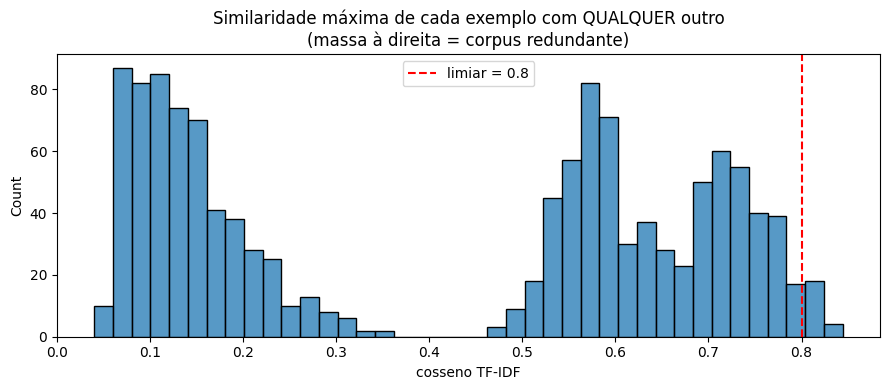

Mediana da similaridade máxima: 0.532
Exemplos com um 'gêmeo' >= 0.8: 24 / 1267 (1.9%)

1254 grupos para 1267 exemplos (maior grupo: 4 exemplos)
Distribuição do tamanho dos grupos:
1    1243
2      10
4       1

Exemplo do maior grupo (id=457) — estes NUNCA podem se separar entre splits:
  • Methods for neighbourhood walkability and physical activity. To better understand moderate-to-vigorous physical activity and daily ...
  • Neighbourhood walkability and physical activity: a a market district case study. Urban data from 1336 participants in a market dis ...
  • Neighbourhood walkability and physical activity. This study in a university precinct explored moderate-to-vigorous physical activi ...


In [12]:
# ============================================================
# 3. AGRUPAMENTO DE QUASE-DUPLICATAS  <-- a correção central
#    Textos sintéticos são variações do mesmo molde. Se variantes do
#    mesmo molde caem em treino e validação, a val_loss vai a zero.
# ============================================================
class UnionFind:
    def __init__(self, n): self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra

texts = df["norm_text"].tolist()
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
X = vec.fit_transform(texts)
S = cosine_similarity(X)
np.fill_diagonal(S, 0.0)

# --- diagnóstico: quão parecidos são os exemplos entre si? ---
max_sim = S.max(axis=1)
plt.figure(figsize=(9, 4))
sns.histplot(max_sim, bins=40)
plt.axvline(DUP_THRESHOLD, color="red", ls="--", label=f"limiar = {DUP_THRESHOLD}")
plt.title("Similaridade máxima de cada exemplo com QUALQUER outro\n(massa à direita = corpus redundante)")
plt.xlabel("cosseno TF-IDF"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Mediana da similaridade máxima: {np.median(max_sim):.3f}")
print(f"Exemplos com um 'gêmeo' >= {DUP_THRESHOLD}: "
      f"{(max_sim >= DUP_THRESHOLD).sum()} / {len(df)} "
      f"({(max_sim >= DUP_THRESHOLD).mean()*100:.1f}%)")

# --- componentes conexos = grupos ---
uf = UnionFind(len(texts))
ii, jj = np.where(np.triu(S, 1) >= DUP_THRESHOLD)
for a, b in zip(ii, jj):
    uf.union(int(a), int(b))
_, groups = np.unique([uf.find(i) for i in range(len(texts))], return_inverse=True)
df["group_id"] = groups

gsize = df.groupby("group_id").size()
print(f"\n{df['group_id'].nunique()} grupos para {len(df)} exemplos "
      f"(maior grupo: {gsize.max()} exemplos)")
print("Distribuição do tamanho dos grupos:")
print(gsize.value_counts().sort_index().head(10).to_string())

if gsize.max() > 1:
    biggest = gsize.idxmax()
    print(f"\nExemplo do maior grupo (id={biggest}) — estes NUNCA podem se separar entre splits:")
    for t in df[df.group_id == biggest]["text"].head(3):
        print("  •", t[:130], "...")

### Como ler o histograma acima

Se a maior parte da massa estiver acima de ~0.7, o corpus é altamente redundante — o LLM gerou variações do mesmo molde. É exatamente isso que produz `val_loss = 0.000001`: o modelo já viu, no treino, uma frase quase idêntica à de validação.

Ajuste `DUP_THRESHOLD` olhando esse gráfico e a inspeção do maior grupo. Se o maior grupo engolir metade do dataset, o limiar está baixo demais; se quase todo grupo tiver tamanho 1 mas o histograma mostrar massa alta, está alto demais.

In [13]:
# ============================================================
# 4. SPLIT POR GRUPO, estratificado, com prioridade dos reais na avaliação
# ============================================================
def group_stratified_split(data, sizes=(0.7, 0.15, 0.15), seed=SEED, eval_priority=True):
    '''Aloca GRUPOS inteiros (nao linhas) para treino/val/teste.
    eval_priority=True empurra os exemplos reais para val/teste.'''
    rng = np.random.default_rng(seed)
    g = (data.groupby("group_id")
             .agg(n=("label_id", "size"),
                  lab=("label_id", lambda s: int(s.mode().iloc[0])),
                  prio=("is_real", "max"))
             .reset_index())
    train_g, val_g, test_g = [], [], []
    for lab, sub in g.groupby("lab"):
        sub = sub.sample(frac=1.0, random_state=int(rng.integers(1e6)))
        if eval_priority:
            sub = sub.sort_values("prio", ascending=False, kind="stable")
        tot = sub["n"].sum()
        q_val, q_test = sizes[1] * tot, sizes[2] * tot
        acc_v = acc_t = 0
        for _, r in sub.iterrows():
            if acc_v < q_val:
                val_g.append(r["group_id"]); acc_v += r["n"]
            elif acc_t < q_test:
                test_g.append(r["group_id"]); acc_t += r["n"]
            else:
                train_g.append(r["group_id"])
    pick = lambda ids: data[data["group_id"].isin(ids)].copy().reset_index(drop=True)
    return pick(train_g), pick(val_g), pick(test_g)


train_df, val_df, test_df = group_stratified_split(
    df, SPLIT_SIZES, eval_priority=(EVAL_PROTOCOL == "real_only")
)

for name, d in [("TREINO", train_df), ("VAL", val_df), ("TESTE", test_df)]:
    pos = (d.label_id == POS_ID).sum()
    real = d.is_real.sum()
    print(f"{name:7s}: {len(d):4d} exemplos | positivos {pos:3d} ({pos/max(len(d),1)*100:4.1f}%) "
          f"| reais {real:3d} ({real/max(len(d),1)*100:4.1f}%)")

TREINO :  885 exemplos | positivos 448 (50.6%) | reais   0 ( 0.0%)
VAL    :  191 exemplos | positivos  96 (50.3%) | reais  67 (35.1%)
TESTE  :  191 exemplos | positivos  96 (50.3%) | reais   0 ( 0.0%)


In [14]:
# ============================================================
# 5. DESCONTAMINAÇÃO do diagnostic_test.json
#    O original concatenava esse arquivo ao teste sem verificar
#    se aqueles exemplos já estavam no treino.
# ============================================================
if os.path.exists(DIAGNOSTIC_PATH):
    diag = pd.DataFrame(load_json_file(DIAGNOSTIC_PATH))
    diag["source"] = "diagnostic"
    diag["norm_text"] = diag["text"].map(normalize_text)
    diag["label_id"] = diag["label"].map(LABEL_MAP)
    diag = diag[diag["label_id"].notna()].copy()
    diag["label_id"] = diag["label_id"].astype(int)
    diag["is_real"] = False
    n0 = len(diag)

    # 5a. sobreposição exata com treino/val
    seen = set(train_df["norm_text"]) | set(val_df["norm_text"])
    diag = diag[~diag["norm_text"].isin(seen)].copy()
    print(f"diagnostic_test: {n0} -> {len(diag)} após remover sobreposição EXATA com treino/val")

    # 5b. sobreposição por QUASE-duplicata com treino/val
    if len(diag):
        ref = pd.concat([train_df, val_df])["norm_text"].tolist()
        v2 = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
        Xall = v2.fit_transform(ref + diag["norm_text"].tolist())
        Sd = cosine_similarity(Xall[len(ref):], Xall[:len(ref)])
        keep = Sd.max(axis=1) < DUP_THRESHOLD
        print(f"                 removendo mais {(~keep).sum()} por quase-duplicata "
              f"(sim. máx. observada: {Sd.max():.3f})")
        diag = diag[keep].copy()

    if len(diag):
        diag["group_id"] = -1  # grupo próprio, nunca colide
        test_df = pd.concat([test_df, diag[test_df.columns.intersection(diag.columns)]],
                            ignore_index=True)
    print(f"Teste final: {len(test_df)} exemplos")
else:
    print("diagnostic_test.json não encontrado — pulando.")

diagnostic_test: 125 -> 125 após remover sobreposição EXATA com treino/val
                 removendo mais 0 por quase-duplicata (sim. máx. observada: 0.183)
Teste final: 316 exemplos


In [15]:
# # ============================================================
# # 6. AUDITORIA DE VAZAMENTO — falha alto se algo escapou
# # ============================================================
# def audit(a, b, name):
#     exact = len(set(a["norm_text"]) & set(b["norm_text"]))
#     grp   = len((set(a["group_id"]) & set(b["group_id"])) - {-1})
#     v = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
#     Z = v.fit_transform(a["norm_text"].tolist() + b["norm_text"].tolist())
#     Sx = cosine_similarity(Z[len(a):], Z[:len(a)])
#     mx = float(Sx.max()) if Sx.size else 0.0
#     near = int((Sx.max(axis=1) >= DUP_THRESHOLD).sum())
#     flag = "❌" if (exact or grp or near) else "✅"
#     print(f"{flag} {name:12s} | texto idêntico: {exact:3d} | grupos comuns: {grp:3d} "
#           f"| quase-dups: {near:3d} | sim. máx.: {mx:.3f}")
#     return exact + grp + near

# total = 0
# total += audit(train_df, val_df,  "treino-val")
# total += audit(train_df, test_df, "treino-teste")
# total += audit(val_df,   test_df, "val-teste")

# assert total == 0, ("Ainda há vazamento entre splits. Baixe DUP_THRESHOLD "
#                     "e rode as células 3-6 de novo.")
# print("\n✅ Splits limpos.")

## 7. Auditoria de separabilidade trivial — rode ISTO antes de treinar o DeBERTa

Dois testes que custam segundos e explicam quase todo resultado "bom demais":

1. **Baseline TF-IDF + regressão logística.** Um modelo linear de saco-de-palavras nos mesmos splits. Se ele já acerta ~100%, as classes são separáveis por vocabulário superficial — o DeBERTa não está aprendendo o construto de *walkability*, está aprendendo que abstracts sintéticos negativos usam outro léxico.
2. **Teste de permutação de rótulos.** Embaralho os rótulos do treino e treino o baseline de novo. Sob rótulos aleatórios, a acurácia de validação **tem** que cair para o nível da classe majoritária. Se não cair, o vazamento é estrutural.

In [16]:
# ============================================================
# 7. Auditoria de separabilidade trivial
# ============================================================
def tfidf_baseline(tr, ev, y_tr=None, seed=SEED):
    y_tr = tr["label_id"].values if y_tr is None else y_tr
    clf = make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed),
    )
    clf.fit(tr["text"], y_tr)
    pred = clf.predict(ev["text"])
    return accuracy_score(ev["label_id"], pred), f1_score(ev["label_id"], pred, average="macro")

majority = max(val_df["label_id"].mean(), 1 - val_df["label_id"].mean())
acc, f1m = tfidf_baseline(train_df, val_df)
print(f"Baseline TF-IDF+LogReg  -> acc {acc:.3f} | F1-macro {f1m:.3f}")
print(f"Classe majoritária      -> acc {majority:.3f}")

# --- teste de permutação ---
rng = np.random.default_rng(SEED)
perm_accs = []
for k in range(10):
    y_shuf = rng.permutation(train_df["label_id"].values)
    a, _ = tfidf_baseline(train_df, val_df, y_tr=y_shuf, seed=SEED + k)
    perm_accs.append(a)
print(f"Rótulos embaralhados    -> acc {np.mean(perm_accs):.3f} ± {np.std(perm_accs):.3f} "
      f"(esperado ≈ {majority:.3f})")

print("\n--- VEREDITO ---")
if acc >= 0.98:
    print("⚠️  Um modelo linear trivial já atinge ~100%. A tarefa, como está montada,")
    print("    é separável por léxico superficial. O 100% do DeBERTa NÃO é evidência")
    print("    de que ele aprendeu 'sensoriamento de dimensão de walkability'.")
    print("    Ação: os negativos sintéticos precisam ser HARD NEGATIVES — artigos de")
    print("    sensoriamento urbano que NÃO medem dimensão de walkability (ex.: sensores")
    print("    de tráfego veicular, qualidade do ar sem vínculo pedestre, imagem aérea).")
elif acc >= 0.90:
    print("⚠️  Baseline linear muito forte. Ganho do DeBERTa provavelmente é marginal —")
    print("    reporte a comparação com o baseline no artigo.")
else:
    print("✅ Tarefa não-trivial. O baseline linear deixa margem real para o transformer.")

if np.mean(perm_accs) > majority + 0.10:
    print("❌ Com rótulos ALEATÓRIOS o baseline ainda vai bem => vazamento estrutural remanescente.")
else:
    print("✅ Teste de permutação passou.")

Baseline TF-IDF+LogReg  -> acc 0.880 | F1-macro 0.878
Classe majoritária      -> acc 0.503
Rótulos embaralhados    -> acc 0.496 ± 0.061 (esperado ≈ 0.503)

--- VEREDITO ---
✅ Tarefa não-trivial. O baseline linear deixa margem real para o transformer.
✅ Teste de permutação passou.


In [17]:
# ============================================================
# 8. Tokenização (tokenizer RÁPIDO + padding dinâmico)
#    Original: DebertaV2Tokenizer (slow) + padding="max_length" em 512
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f"Tokenizer rápido: {tokenizer.is_fast}")

class TextClsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LEN):
        self.texts = list(texts); self.labels = list(labels)
        self.tok = tokenizer; self.max_length = max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], truncation=True,
                       max_length=self.max_length)   # SEM padding -> collator faz por batch
        enc["labels"] = int(self.labels[idx])
        return enc

train_dataset = TextClsDataset(train_df["text"], train_df["label_id"], tokenizer)
val_dataset   = TextClsDataset(val_df["text"],   val_df["label_id"],   tokenizer)
test_dataset  = TextClsDataset(test_df["text"],  test_df["label_id"],  tokenizer)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

# quanto do texto está sendo truncado?
lens = [len(tokenizer(t, truncation=False)["input_ids"]) for t in df["text"]]
print(f"Tokens: mediana {int(np.median(lens))} | p95 {int(np.percentile(lens,95))} "
      f"| máx {max(lens)} | truncados em {MAX_LEN}: {sum(l>MAX_LEN for l in lens)}")

C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer rápido: True
Tokens: mediana 105 | p95 188 | máx 478 | truncados em 384: 8


In [18]:
# ============================================================
# 9. Focal loss corrigida
#    Bugs do original: pt via gather sobre softmax junto com CE separada
#    (numericamente instável), inputs não copiados, assinatura incompatível
#    com versões novas do Trainer (num_items_in_batch), e label_smoothing
#    do TrainingArguments silenciosamente ignorado.
# ============================================================
class FocalLossTrainer(Trainer):
    def __init__(self, *args, gamma=2.0, alpha=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
        self.alpha = alpha  # tensor (num_classes,) ou None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs["labels"]
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}
        outputs = model(**model_inputs)
        logits = outputs.logits

        logp = F.log_softmax(logits, dim=-1)
        logpt = logp.gather(1, labels.unsqueeze(1)).squeeze(1)
        pt = logpt.exp()
        w = (1.0 - pt) ** self.gamma
        if self.alpha is not None:
            w = w * self.alpha.to(logits.device)[labels]
        loss = -(w * logpt).mean()
        return (loss, outputs) if return_outputs else loss

# pesos de classe (compensam desbalanceamento; substituem o class_weight ausente no original)
counts = train_df["label_id"].value_counts().sort_index().values.astype(float)
alpha = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float)
print(f"Contagens por classe: {counts.tolist()} | alpha: {alpha.tolist()}")

Contagens por classe: [437.0, 448.0] | alpha: [1.0125857591629028, 0.9877232313156128]


In [19]:
# ============================================================
# 10. Métricas adequadas para SCREENING de revisão sistemática
#     Original: só accuracy. Numa triagem, o que importa é RECALL da
#     classe positiva (não perder artigo elegível).
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = probs.argmax(axis=1)
    out = {
        "accuracy":  accuracy_score(labels, preds),
        "f1_macro":  f1_score(labels, preds, average="macro", zero_division=0),
        "f1_pos":    f1_score(labels, preds, pos_label=POS_ID, zero_division=0),
        "precision_pos": precision_score(labels, preds, pos_label=POS_ID, zero_division=0),
        "recall_pos":    recall_score(labels, preds, pos_label=POS_ID, zero_division=0),
        "mcc":       matthews_corrcoef(labels, preds),
    }
    if len(np.unique(labels)) > 1:
        out["pr_auc"] = average_precision_score((labels == POS_ID).astype(int), probs[:, POS_ID])
    return out

In [20]:
# ============================================================
# 11. Modelo + argumentos de treino (corrigidos)
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_MAP),
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
    # CORREÇÃO: dropout PRECISA ser passado aqui. No original era atribuído
    # a model.config DEPOIS do from_pretrained, o que não tem efeito algum.
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.05,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    # CORREÇÃO: seleciona pelo F1-macro, não pela loss (que colapsa com vazamento)
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=10,
    logging_first_step=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    # REMOVIDO: label_smoothing_factor (é ignorado quando há compute_loss custom)
    # REMOVIDO: eval_steps / save_steps (ignorados com strategy="epoch")
    # REMOVIDO: no_cuda (depreciado)
)

trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    gamma=2.0,
    alpha=alpha,
)
# compatibilidade entre versões: `tokenizer=` foi renomeado para `processing_class=`
try:
    trainer.processing_class = tokenizer
except Exception:
    trainer.tokenizer = tokenizer

print("Treinando...")
trainer.train()
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")
print(f"Modelo salvo em {OUTPUT_DIR}/best_model")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Treinando...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Pos,Precision Pos,Recall Pos,Mcc,Pr Auc
1,0.038900,0.680659,0.691099,0.657279,0.764940,0.619355,1.000000,0.484461,0.862680
2,0.064100,0.290498,0.848168,0.847347,0.858537,0.807339,0.916667,0.702661,0.960845
3,0.066500,0.412450,0.863874,0.861871,0.845238,0.986111,0.739583,0.752176,0.948027
4,0.000000,0.388939,0.858639,0.856738,0.840237,0.972603,0.739583,0.739333,0.955274
5,0.000000,0.316842,0.874346,0.873566,0.863636,0.950000,0.791667,0.759623,0.958495
6,0.000000,0.315448,0.874346,0.873761,0.865169,0.939024,0.802083,0.757044,0.958925
7,0.000000,0.317299,0.874346,0.873761,0.865169,0.939024,0.802083,0.757044,0.958990
8,0.000000,0.317496,0.874346,0.873761,0.865169,0.939024,0.802083,0.757044,0.958925


Modelo salvo em ../model/output/best_model


Temperatura ótima (ajustada na VALIDAÇÃO): 1.6750 | NLL 0.3306



=== Relatório de classificação (TESTE) ===
                                  precision    recall  f1-score   support

                     Not related      0.802     0.947     0.869       171
Sensing of walkability dimension      0.921     0.724     0.811       145

                        accuracy                          0.845       316
                       macro avg      0.862     0.836     0.840       316
                    weighted avg      0.857     0.845     0.842       316



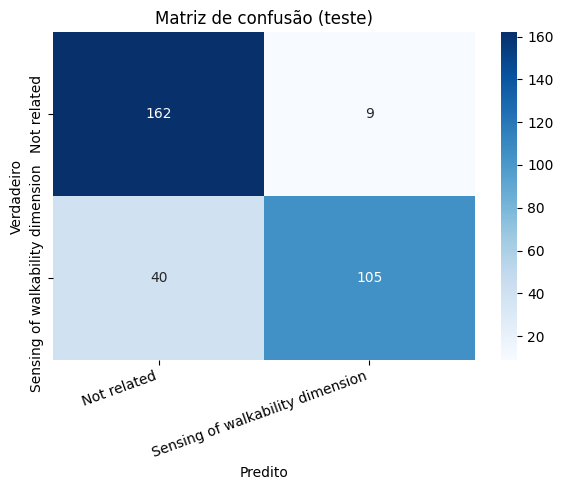

In [21]:
# ============================================================
# 12. Calibração por temperatura — usando a variável calculada
#     (o original computava `temperature` e depois dividia por 0.602 fixo)
# ============================================================
def fit_temperature(logits, labels, grid=np.linspace(0.5, 5.0, 181)):
    lt = torch.tensor(logits, dtype=torch.float32)
    ly = torch.tensor(labels, dtype=torch.long)
    nlls = [F.cross_entropy(lt / float(T), ly).item() for T in grid]
    return float(grid[int(np.argmin(nlls))]), float(np.min(nlls))

val_out = trainer.predict(val_dataset)
temperature, nll = fit_temperature(val_out.predictions, val_out.label_ids)
print(f"Temperatura ótima (ajustada na VALIDAÇÃO): {temperature:.4f} | NLL {nll:.4f}")

test_out = trainer.predict(test_dataset)
test_logits, test_labels = test_out.predictions, test_out.label_ids

# CORREÇÃO: usa a variável, não um número mágico
test_probs = torch.softmax(torch.tensor(test_logits) / temperature, dim=-1).numpy()
test_preds = test_probs.argmax(axis=1)

print("\n=== Relatório de classificação (TESTE) ===")
names = [ID_TO_LABEL[i] for i in sorted(ID_TO_LABEL)]
print(classification_report(test_labels, test_preds, target_names=names,
                            digits=3, zero_division=0))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names)
plt.xlabel("Predito"); plt.ylabel("Verdadeiro"); plt.title("Matriz de confusão (teste)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

In [22]:
# ============================================================
# 13. Intervalo de confiança por bootstrap
#     Com ~30 exemplos de teste, um ponto isolado ("F1 = 1.00") não
#     significa nada sem incerteza. Reporte o IC no artigo.
# ============================================================
def bootstrap_ci(y_true, y_pred, metric, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric(y_true[idx], y_pred[idx]))
    return np.mean(vals), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

for label, fn in [
    ("F1-macro",     lambda a, b: f1_score(a, b, average="macro", zero_division=0)),
    ("Recall (pos)", lambda a, b: recall_score(a, b, pos_label=POS_ID, zero_division=0)),
    ("Precisão (pos)", lambda a, b: precision_score(a, b, pos_label=POS_ID, zero_division=0)),
]:
    m, lo, hi = bootstrap_ci(test_labels, test_preds, fn)
    print(f"{label:16s}: {m:.3f}  IC95% [{lo:.3f}, {hi:.3f}]")

F1-macro        : 0.839  IC95% [0.798, 0.881]
Recall (pos)    : 0.725  IC95% [0.653, 0.794]
Precisão (pos)  : 0.920  IC95% [0.867, 0.966]


## 14. Escolha do limiar para triagem

Para uma revisão sistemática, errar para o lado do falso positivo é barato (você lê um abstract a mais) e errar para o lado do falso negativo é caro (perde artigo elegível). O `argmax` padrão (limiar 0.5) não é a escolha certa: ajuste o limiar na **validação** para garantir recall alto e reporte a precisão resultante.

Limiar escolhido: 0.09 (val recall 0.979, precisão 0.701)

No TESTE com esse limiar -> recall 0.993 | precisão 0.699


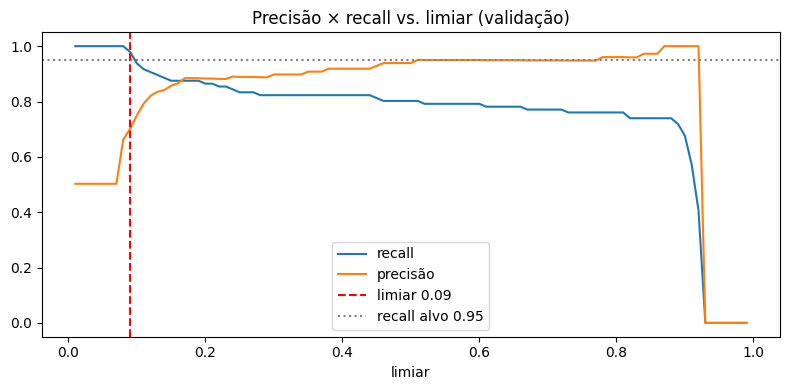

In [23]:
# ============================================================
# 14. Limiar operacional ajustado na VALIDAÇÃO, aplicado no TESTE
# ============================================================
val_probs = torch.softmax(torch.tensor(val_out.predictions) / temperature, dim=-1).numpy()[:, POS_ID]
val_y = (val_out.label_ids == POS_ID).astype(int)

TARGET_RECALL = 0.95
rows = []
for thr in np.linspace(0.01, 0.99, 99):
    p = (val_probs >= thr).astype(int)
    rows.append({"thr": thr,
                 "recall": recall_score(val_y, p, zero_division=0),
                 "precision": precision_score(val_y, p, zero_division=0)})
sweep = pd.DataFrame(rows)
ok = sweep[sweep["recall"] >= TARGET_RECALL]
chosen = ok.sort_values("precision", ascending=False).iloc[0] if len(ok) else sweep.iloc[49]
print(f"Limiar escolhido: {chosen['thr']:.2f} "
      f"(val recall {chosen['recall']:.3f}, precisão {chosen['precision']:.3f})")

test_pos = test_probs[:, POS_ID]
test_thr_preds = (test_pos >= chosen["thr"]).astype(int)
ty = (test_labels == POS_ID).astype(int)
print(f"\nNo TESTE com esse limiar -> recall {recall_score(ty, test_thr_preds, zero_division=0):.3f} "
      f"| precisão {precision_score(ty, test_thr_preds, zero_division=0):.3f}")

plt.figure(figsize=(8, 4))
plt.plot(sweep["thr"], sweep["recall"], label="recall")
plt.plot(sweep["thr"], sweep["precision"], label="precisão")
plt.axvline(chosen["thr"], color="red", ls="--", label=f"limiar {chosen['thr']:.2f}")
plt.axhline(TARGET_RECALL, color="gray", ls=":", label=f"recall alvo {TARGET_RECALL}")
plt.xlabel("limiar"); plt.legend(); plt.title("Precisão × recall vs. limiar (validação)")
plt.tight_layout(); plt.show()

## 15. Validação cruzada agrupada — o estimador que você deve reportar

Com ~180 exemplos, um único split de 15% para teste tem incerteza enorme. `StratifiedGroupKFold` respeita os grupos de quase-duplicatas **e** usa todo o dataset para avaliação ao longo dos folds. Rode isto para o número final do artigo (é caro: 5 treinos).

In [24]:
# ============================================================
# 15. StratifiedGroupKFold (opcional — ligue quando for reportar)
# ============================================================
RUN_CV = False   # <- mude para True quando for gerar os números finais
N_FOLDS = 5

if RUN_CV:
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_metrics = []
    for fold, (tr_i, te_i) in enumerate(sgkf.split(df, df["label_id"], groups=df["group_id"])):
        print(f"\n===== Fold {fold+1}/{N_FOLDS} =====")
        tr_fold = df.iloc[tr_i].reset_index(drop=True)
        te_fold = df.iloc[te_i].reset_index(drop=True)
        # sub-split interno para validação (também por grupo)
        inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
        i_tr, i_va = next(inner.split(tr_fold, tr_fold["label_id"], groups=tr_fold["group_id"]))
        tr2, va2 = tr_fold.iloc[i_tr], tr_fold.iloc[i_va]

        m = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=len(LABEL_MAP),
            id2label=ID_TO_LABEL, label2id=LABEL_MAP,
            hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1)
        import copy
        args_f = copy.deepcopy(training_args)   # to_dict() quebra entre versoes
        args_f.output_dir = f"{OUTPUT_DIR}/fold{fold}"
        c = tr2["label_id"].value_counts().sort_index().values.astype(float)
        t = FocalLossTrainer(
            model=m, args=args_f,
            train_dataset=TextClsDataset(tr2["text"], tr2["label_id"], tokenizer),
            eval_dataset=TextClsDataset(va2["text"], va2["label_id"], tokenizer),
            data_collator=data_collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
            gamma=2.0, alpha=torch.tensor(c.sum() / (len(c) * c), dtype=torch.float))
        t.train()
        r = t.evaluate(TextClsDataset(te_fold["text"], te_fold["label_id"], tokenizer))
        print({k: round(v, 3) for k, v in r.items() if k.startswith("eval_")})
        fold_metrics.append(r)

    cv = pd.DataFrame(fold_metrics)
    print("\n===== Resumo da validação cruzada =====")
    for c_ in ["eval_f1_macro", "eval_recall_pos", "eval_precision_pos", "eval_mcc"]:
        if c_ in cv:
            print(f"{c_:22s}: {cv[c_].mean():.3f} ± {cv[c_].std():.3f}")
else:
    print("RUN_CV=False — pulando validação cruzada.")

RUN_CV=False — pulando validação cruzada.


In [25]:
# ============================================================
# 16. Análise de erros
# ============================================================
results_df = test_df[["text", "label", "label_id", "source"]].copy().reset_index(drop=True)
results_df["pred_id"]   = test_preds
results_df["pred_label"] = results_df["pred_id"].map(ID_TO_LABEL)
results_df["correct"]   = results_df["label_id"] == results_df["pred_id"]
results_df["confidence"] = test_probs.max(axis=1)     # CORREÇÃO: probs calibradas
results_df["p_pos"]      = test_probs[:, POS_ID]

mis = results_df[~results_df["correct"]]
print(f"Erros: {len(mis)} de {len(results_df)}")
for _, r in mis.head(8).iterrows():
    print(f"\n[{r['source']}] verdadeiro={r['label']} | predito={r['pred_label']} "
          f"(conf {r['confidence']:.3f})")
    print("  ", r["text"][:200], "...")

# desempenho por origem: o que interessa é a coluna 'real'
print("\nAcurácia por origem do exemplo:")
print(results_df.groupby("source")["correct"].agg(["mean", "count"]).round(3))

# casos de menor confiança = candidatos a revisão manual
print("\nMenor confiança (revisar manualmente):")
for _, r in results_df.nsmallest(5, "confidence").iterrows():
    print(f"  {r['confidence']:.3f} | verdadeiro={r['label']} | predito={r['pred_label']}")

Erros: 49 de 316

[contrastive] verdadeiro=Sensing of walkability dimension | predito=Not related (conf 0.900)
   A vehicle-mounted camera dataset was annotated and used to train a detector for tactile paving continuity on urban sidewalks. ...

[contrastive] verdadeiro=Sensing of walkability dimension | predito=Not related (conf 0.714)
   Panoramic imagery was processed to compute green view index and sky view factor at pedestrian eye level across a dense urban district. ...

[dataset] verdadeiro=Sensing of walkability dimension | predito=Not related (conf 0.605)
   Deriving effective pedestrian network connectivity from imagery-detected sidewalk presence. Conventional connectivity measures are computed on road centrelines and assume that every street is walkable ...

[diagnostic] verdadeiro=Sensing of walkability dimension | predito=Not related (conf 0.797)
   Mapping sidewalks on a neighborhood scale from street view images. Although reliable and accurate inventorying of sidewalks is

In [26]:
# ============================================================
# 17. Inferência + artefatos de deploy (max_length consistente)
# ============================================================
def predict(texts, model=None, tok=None, temp=None, threshold=None):
    model = model or trainer.model
    tok = tok or tokenizer
    temp = temperature if temp is None else temp
    threshold = float(chosen["thr"]) if threshold is None else threshold
    single = isinstance(texts, str)
    texts = [texts] if single else list(texts)

    model.eval().to(device)
    enc = tok(texts, truncation=True, padding=True,
              max_length=MAX_LEN, return_tensors="pt").to(device)   # MESMO MAX_LEN do treino
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits / temp, dim=-1).cpu().numpy()

    out = [{"predicted_label": ID_TO_LABEL[POS_ID] if p[POS_ID] >= threshold
                               else ID_TO_LABEL[1 - POS_ID],
            "p_positive": float(p[POS_ID]),
            "probabilities": {ID_TO_LABEL[i]: float(v) for i, v in enumerate(p)}}
           for p in probs]
    return out[0] if single else out

json.dump({
    "model_name": MODEL_NAME,
    "num_labels": len(LABEL_MAP),
    "id2label": {str(k): v for k, v in ID_TO_LABEL.items()},
    "label2id": LABEL_MAP,
    "max_length": MAX_LEN,
    "temperature": float(temperature),
    "decision_threshold": float(chosen["thr"]),
    "positive_class_id": POS_ID,
}, open(f"{OUTPUT_DIR}/model_config.json", "w"), indent=2)
print(f"Config salva em {OUTPUT_DIR}/model_config.json")

# splits persistidos para auditoria/reprodutibilidade no artigo
for name, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    d.drop(columns=["norm_text"], errors="ignore").to_json(
        f"{DATA_DIR}/{name}.json", orient="records", indent=2, force_ascii=False)
print(f"Splits salvos em {DATA_DIR}/")

for r in predict([
    "This study deploys LiDAR and street-level imagery to quantify sidewalk width, "
    "shade coverage and surface quality along pedestrian corridors.",
    "We evaluate gait parameters in post-stroke patients using an instrumented walkway "
    "in a clinical laboratory setting.",
]):
    print(f"\n{r['predicted_label']}  (p_pos = {r['p_positive']:.3f})")

Config salva em ../model/output/model_config.json
Splits salvos em ../model/dataset/

Sensing of walkability dimension  (p_pos = 0.379)

Sensing of walkability dimension  (p_pos = 0.094)


---

## O que fazer com o resultado da célula 7

Se o veredito da auditoria for **"tarefa trivialmente separável"** (o cenário mais provável, dado o `val_loss = 1e-6`), corrigir o split sozinho não resolve o problema de fundo: o dataset é fácil demais. As correções que valem:

1. **Hard negatives.** Os negativos precisam ser artigos que um humano precisaria pensar para rejeitar: sensoriamento urbano que não mede dimensão de walkability (sensores de tráfego veicular, monitoramento de qualidade do ar sem vínculo pedestre, aquisição puramente aérea/satelital), imagem de rua usada como estímulo de *survey* em vez de dado de medição, e auditoria de rua para construtos não-walkability (risco de crime, valor imobiliário). São exatamente as três regras de adjudicação que você já formalizou — elas deveriam gerar os negativos, não só filtrar os positivos.

2. **Mais anotação real.** 67 abstracts reais é pouco para estimar desempenho. Amostre ~300 do corpus de ~1.600 e rotule manualmente. Use os sintéticos só como pré-treino/aumento, nunca na avaliação.

3. **Reporte o baseline.** Um revisor vai perguntar. Se o TF-IDF+LogReg chega perto do DeBERTa no conjunto real, isso é um achado a reportar, não a esconder.

4. **Reporte concordância humana.** Rotule um subconjunto duas vezes (ou com um segundo anotador) e calcule Cohen's κ. O teto do classificador é a consistência da anotação — e revisores sistemáticos esperam esse número.